In [1]:
import pandas as pd
import numpy as np
import os 
import plotnine as p9
from sklearn import preprocessing
from sklearn.decomposition import PCA

# 0.Processing

In [15]:
# ===== CSV → TSV 转换 =====
csv_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.csv"
tsv_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.tsv"

# 读取 CSV（保留行名）
df = pd.read_csv(csv_path, index_col=0)

# 保存为 TSV
df.to_csv(tsv_path, sep="\t")

print(f"CSV 已成功转换为 TSV：\n{tsv_path}")

CSV 已成功转换为 TSV：
/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.tsv


In [29]:
# 1. 读取原始表达矩阵
expr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.tsv",sep="\t",index_col=0)

# 2. 读取基因得分文件（无表头格式）
gene_scores_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_increase_coupling_kwx.csv"
gene_scores = pd.read_csv(gene_scores_path, header=None, names=['gene', 'score'], index_col=0)

print(f"基因得分文件已读取: {len(gene_scores)} 个基因")
print(f"得分统计: 均值={gene_scores['score'].mean():.4f}, 最大值={gene_scores['score'].max():.4f}, 最小值={gene_scores['score'].min():.4f}")

基因得分文件已读取: 927 个基因
得分统计: 均值=1.2094, 最大值=13.5596, 最小值=-12.5492


In [30]:
# 3. 使用得分文件中的所有基因
all_genes = gene_scores.index

# 4. 从表达矩阵中筛选这些基因（取交集，避免表达矩阵中不存在的基因报错）
common_genes = expr.index.intersection(all_genes)
expr_sel = expr.loc[common_genes]

print(f"原始表达矩阵基因数: {expr.shape[0]}")
print(f"得分文件基因数: {len(all_genes)}")
print(f"匹配到的基因数: {len(common_genes)}")
print(f"匹配率 (matched / score_file): {len(common_genes)/len(all_genes):.2%}")

原始表达矩阵基因数: 13787
得分文件基因数: 927
匹配到的基因数: 810
匹配率 (matched / score_file): 87.38%


In [31]:
# 5. 解析列名获取脑区和发育阶段
def extract_metadata(col_name: str):
    """解析列名格式：脑区|发育阶段"""
    if '|' in col_name:
        parts = col_name.split('|')
        region = parts[0].strip()
        stage = parts[1].strip() if len(parts) > 1 else "Unknown"
        return region, stage
    return "Unknown", "Unknown"

In [32]:
# 6. 创建元数据表
metadata = []
for col in expr.columns:
    region, stage = extract_metadata(col)
    metadata.append({'column': col, 'region': region, 'stage': stage})

metadata_df = pd.DataFrame(metadata)

# 打印脑区和阶段信息
print("\n脑区统计:")
print(metadata_df['region'].value_counts())

print("\n发育阶段统计:")
print(metadata_df['stage'].value_counts())


脑区统计:
region
A1C    4
AMY    4
CBC    4
DFC    4
HIP    4
IPC    4
ITC    4
M1C    4
MD     4
MFC    4
OFC    4
S1C    4
STC    4
STR    4
V1C    4
VFC    4
Name: count, dtype: int64

发育阶段统计:
stage
11-18    16
18-30    16
2-8      16
36-40    16
Name: count, dtype: int64


In [33]:
# 7. 构建结果矩阵框架
regions = sorted(metadata_df['region'].unique())
stages = sorted(
    metadata_df['stage'].unique(),
    key=lambda x: int(x.split('-')[0]) if '-' in x else 0
)

result_matrix = pd.DataFrame(index=regions, columns=stages, dtype=float)

# 1.Calculate

In [34]:
# 8. 计算每个脑区-阶段组合的平均表达值（基于“得分文件中的所有基因”）
print("\n正在计算各脑区发育阶段平均表达值...")
for region in regions:
    for stage in stages:
        cols = metadata_df[
            (metadata_df['region'] == region) &
            (metadata_df['stage'] == stage)
        ]['column']

        if not cols.empty:
            sub_expr = expr_sel[cols]

            # 先对样本列求均值，再对基因求均值 -> 得到一个标量
            result_matrix.loc[region, stage] = sub_expr.mean(axis=1).mean()
        else:
            print(f"警告: 脑区 {region} 阶段 {stage} 无数据")
            result_matrix.loc[region, stage] = np.nan


正在计算各脑区发育阶段平均表达值...


# 2.Save

In [35]:
# 9. 保存结果
output_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_increase_kwx.csv"
result_matrix.to_csv(output_path)

# 10. 结果验证
print("\n计算完成! 结果摘要:")
print(f"结果矩阵维度: {result_matrix.shape[0]} 脑区 x {result_matrix.shape[1]} 阶段")
print(f"非空值比例: {result_matrix.notna().sum().sum() / result_matrix.size:.2%}")
print(f"结果已保存至: {output_path}")

print("\n矩阵预览:")
print(result_matrix.head())


计算完成! 结果摘要:
结果矩阵维度: 16 脑区 x 4 阶段
非空值比例: 100.00%
结果已保存至: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_decrease_kwx.csv

矩阵预览:
          2-8     11-18     18-30     36-40
A1C  2.838380  2.696736  2.857424  2.802768
AMY  2.762164  2.767564  2.815183  2.856063
CBC  2.778909  2.766167  2.857017  2.868170
DFC  2.595061  2.843414  2.831225  2.815718
HIP  2.675021  2.685584  2.843724  2.813832


# 3.PCA

In [75]:
# ===== CSV → TSV 转换 =====
csv_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_increase_kwx.csv"
tsv_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_increase_kwx.tsv"

# 读取 CSV（保留行名）
df = pd.read_csv(csv_path, index_col=0)

# 保存为 TSV
df.to_csv(tsv_path, sep="\t")

print(f"CSV 已成功转换为 TSV：\n{tsv_path}")

CSV 已成功转换为 TSV：
/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_increase_kwx.tsv


In [76]:
# 1. 读取数据
expr = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/11.PCA/brainspan_for_PCA_increase_kwx.tsv", sep="\t", index_col=0)

# --- 诊断信息 (可选，但有助于理解) ---
print("--- 数据结构诊断 ---")
print("数据行名 (应为脑区样本):", list(expr.index[:5]), "...")
print("数据列名 (应为年龄分组):", list(expr.columns))
print("-" * 30)

--- 数据结构诊断 ---
数据行名 (应为脑区样本): ['A1C', 'AMY', 'CBC', 'DFC', 'HIP'] ...
数据列名 (应为年龄分组): ['2-8', '11-18', '18-30', '36-40']
------------------------------


In [77]:
# 2. PCA分析
# !! 关键改动 !!：不再使用 .T 对数据进行转置。
# 我们直接对 expr 进行操作，这样每个点就代表一个脑区（行）。
expr_scale = preprocessing.scale(expr, axis=0)

# n_components 的上限是 min(样本数, 特征数)。
# 样本数现在是脑区数 (expr的行数)，特征数是年龄分组数 (4)。所以n_components最大为4。
pca_obj = PCA(n_components=4, svd_solver="full")
pca_obj.fit(expr_scale)
components = pca_obj.transform(expr_scale)

In [78]:
# 3. 构建绘图所需的数据框 (DataFrame)
# 定义脑区分组的映射关系
region_to_group_map = {
    'VFC': 'FP', 'IPC': 'FP', 'DFC': 'FP', 'OFC': 'FP', 'MFC': 'FP',
    'A1C': 'Primary', 'V1C': 'Primary', 'M1C': 'Primary', 'S1C': 'Primary',
    'CBC': 'Subcortex', 'STR': 'Subcortex', 'MD': 'Subcortex', 'AMY': 'Subcortex', 'HIP': 'Subcortex',
    'STC': 'Temporal', 'ITC': 'Temporal'
}

# 创建基础DataFrame
pca_dat = pd.DataFrame(components[:, :2], columns=['PC1', 'PC2'])

# !! 关键改动 !!：从 expr.index (行名) 而不是 expr.columns (列名) 获取信息
# 'Sample' 列存储完整的脑区样本名，如 'VFC-1'
pca_dat['Sample'] = expr.index
# 'Region' 列存储提取出的简称，如 'VFC'
pca_dat['Region'] = pca_dat['Sample'].str.split('-', expand=True)[0]

# 使用正确的 'Region' 列进行映射，并处理未分类的脑区
pca_dat['Group'] = pca_dat['Region'].map(region_to_group_map).fillna('Unknown')

# 打印未分类的脑区以供检查
unmapped_regions = pca_dat[pca_dat['Group'] == 'Unknown']['Region'].unique()
if len(unmapped_regions) > 0:
    print(f"!!! 警告 !!!")
    print(f"以下脑区简称 '{list(unmapped_regions)}' 未在分组字典中定义，已被自动归类为 'Unknown'。")
    print("-" * 30)

In [79]:
# 4. 使用 Plotnine 绘图
colors = {"FP": "#F5A238", "Primary": "#7e9e4d", "Temporal": "#A57EB5", "Subcortex": "#93B8E4"}
x_limits = (-4, 2)
y_limits = (-2, 2)

pca_plot = ( p9.ggplot(pca_dat, p9.aes(x="PC1", y="PC2", color="Group"))
             + p9.geom_point(shape="o", size=8, alpha=1, stroke=0)
             + p9.geom_text(p9.aes(label="Region"), color="black", size=13, family="Arial", fontweight="normal")
             + p9.xlab(f"PC1: {pca_obj.explained_variance_ratio_[0]:.1%} variance")
             + p9.ylab(f"PC2: {pca_obj.explained_variance_ratio_[1]:.1%} variance")
             + p9.scale_color_manual(values=colors)
             + p9.coord_fixed(ratio=1.0, xlim=x_limits, ylim=y_limits)
             + p9.theme_classic()
             + p9.theme(text=p9.element_text(family="Arial", weight="bold"),
                        axis_title=p9.element_text(color="black", size=15, family="Arial", weight="bold"),
                        axis_text=p9.element_text(color="black", size=12, family="Arial", weight="normal"),
                        legend_title=p9.element_text(family="Arial", size=15, weight="bold"),
                        legend_text=p9.element_text(family="Arial", size=12, weight="normal"),
                        legend_position="right")
)

图像已成功保存至: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/3.2pca_expr_increase.png


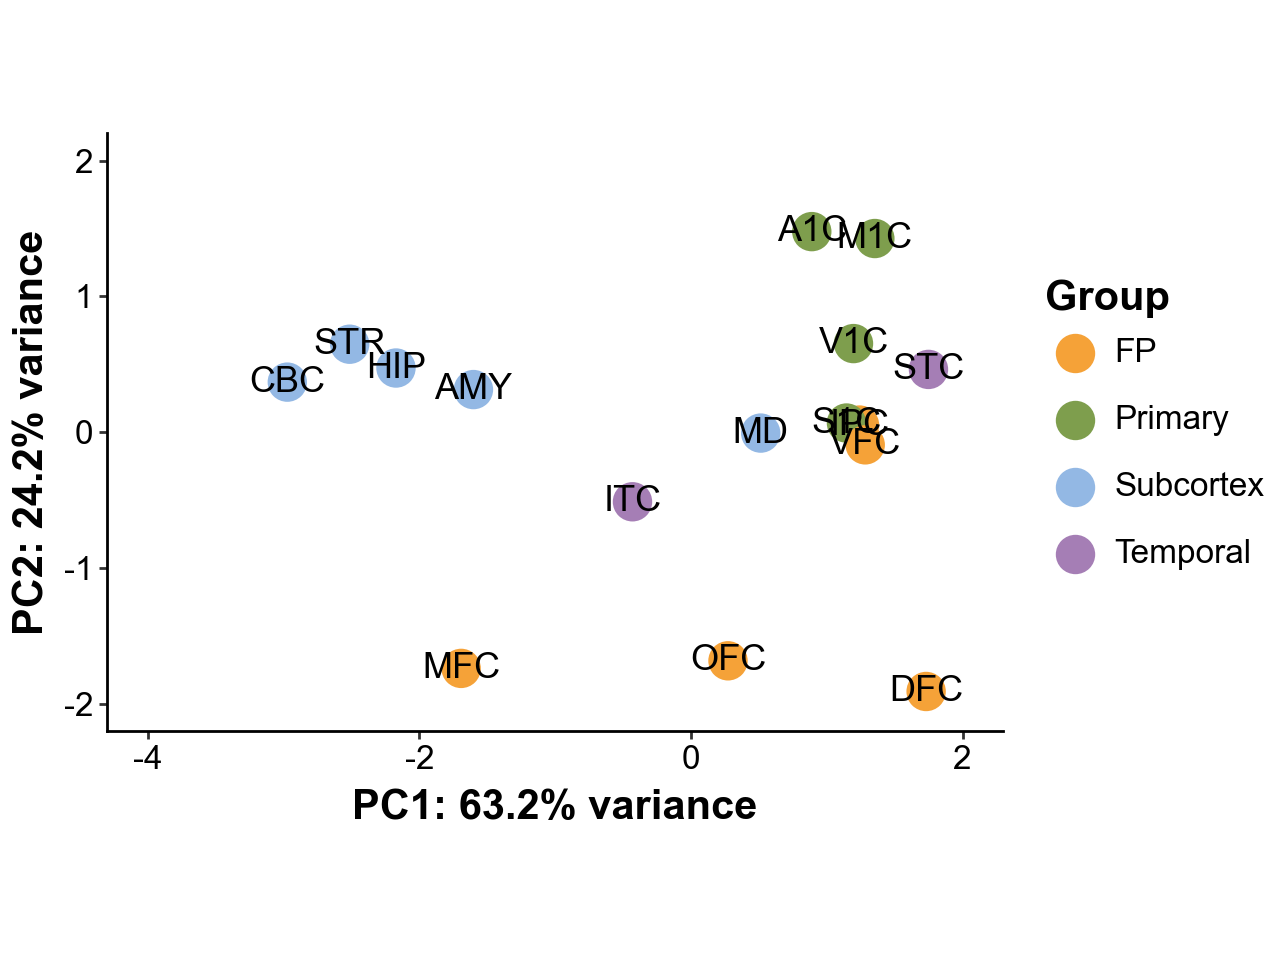

In [80]:
# 5. 保存和显示图像
save_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/3.2pca_expr_increase.png"
p9.ggsave(pca_plot, save_path, units="in", width=7, height=5, dpi=1200, verbose=False)
print(f"图像已成功保存至: {save_path}")

pca_plot